# EXAMEN UNIDAD 5 · TicoShop · ¿Qué clientes van a dejar de comprar?

# Caso: TicoShop tiene 2000 clientes y quiere detectar a tiempo a los que probablemente dejen de comprar, para contactarlos y ofrecerles una promoción.

 Pasos que se siguen siempre:
cargar datos → explorar → segmentar →
separar X e Y → apartar prueba →
entrenar varios modelos → predecir y evaluar (con random_state=42).

In [4]:
#Celda 1, para cargar el archivo con el boton de Colab
from google.colab import files                                            # Botón para subir archivos en Colab
import io                                                                 # Leer archivos desde memoria
import pandas as pd                                                       # Manejo de tablas (DataFrames)

print("Selecciona el archivo de TicoShop (Excel o CSV) :")

archivos_subidos = files.upload() # abre el boton de "Elegir archivos"

#Obtener el nombre del archivo
TicoShop_Clientes = list(archivos_subidos.keys())[0]
print(f"\n Archivo cargado: {TicoShop_Clientes}")

Selecciona el archivo de TicoShop (Excel o CSV) :


Saving TicoShop_Clientes.xlsx to TicoShop_Clientes (3).xlsx

 Archivo cargado: TicoShop_Clientes (3).xlsx


In [14]:
#Celda 2, leer el archivo segun su extension
if TicoShop_Clientes.endswith("csv"):
  df_clientes = pd.read_csv(io.BytesIO(archivos_subidos[TicoShop_Clientes]))
elif TicoShop_Clientes.endswith((".xlsx", ".xls")):
  df_clientes = pd.read_excel(io.BytesIO(archivos_subidos[TicoShop_Clientes]))
else:
  raise ValueError("Formato de archivo no soportado")

#Verificar que la tabla se ha cargado bien
print("Data Set")
print(df_clientes.shape)
print("-" * 60)
print("Primeras Filas")
display(df_clientes.head())
print("-" * 60)
print("Ultimas Filas")
display(df_clientes.tail())
print("-" * 60)
print("Columnas Disponibles")
print(list(df_clientes.columns))

Data Set
(2000, 8)
------------------------------------------------------------
Primeras Filas


,cliente_id,recencia,frecuencia,monto,antiguedad_meses,quejas,usa_app,se_fue
0,C0001,26,10,217500,35,0,0,0
1,C0002,33,5,346900,5,0,1,0
2,C0003,54,8,212800,29,0,0,0
3,C0004,17,2,116800,1,0,0,0
4,C0005,62,10,118300,40,0,0,0


------------------------------------------------------------
Ultimas Filas


,cliente_id,recencia,frecuencia,monto,antiguedad_meses,quejas,usa_app,se_fue
1995,C1996,53,9,222200,33,0,0,0
1996,C1997,226,2,35700,29,1,1,1
1997,C1998,23,4,265000,3,0,0,0
1998,C1999,3,16,534000,47,1,1,0
1999,C2000,36,7,87300,15,0,1,1


------------------------------------------------------------
Columnas Disponibles
['cliente_id', 'recencia', 'frecuencia', 'monto', 'antiguedad_meses', 'quejas', 'usa_app', 'se_fue']


In [15]:
#Celda 3, para cargar el resto de librerias
import numpy as np                                                        # Operaciones numéricas
import matplotlib.pyplot as plt                                           # Gráficos
import seaborn as sns                                                     # Gráficos más bonitos

from sklearn.preprocessing import StandardScaler                          # Escalar variables (obligatorio para K-Means y KNN)
from sklearn.cluster import KMeans                                        # Segmentación no supervisada
from sklearn.model_selection import train_test_split, cross_val_score     # Separar train/test y validación cruzada
from sklearn.linear_model import LogisticRegression                       # Modelo 1: Regresión logística
from sklearn.tree import DecisionTreeClassifier, plot_tree                # Modelo 2 y 3: Árbol de decisión
from sklearn.ensemble import RandomForestClassifier                       # Modelo 4: Random Forest
from sklearn.neighbors import KNeighborsClassifier                        # Modelo 5: K vecinos más cercanos
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve)                    # Métricas de evaluación



sns.set_style("whitegrid")                                                # Estilo de los gráficos
plt.rcParams["figure.figsize"] = (10, 6)                                  # # Tamaño por defecto de las figuras


#**PARTE A · ENTENDER EL PROBLEMA (Unidad 1)**



1. ¿Es regresión o clasificación? ¿Por qué?

Es un problema de CLASIFICACIÓN. Lo que se quiere predecir es una categoría
con solo dos opciones posibles: el cliente se fue (1) o se quedó (0).
No se predice un número continuo (como ventas o precios), que sería regresión.

2. Identifica X e Y

X (variables independientes, las pistas):
   recencia, frecuencia, monto, antiguedad_meses, quejas, usa_app.
   Son datos que TicoShop ya conoce del cliente ANTES de que decida irse.

Y (variable dependiente, lo que se quiere predecir):
   se_fue (1 = se fue, 0 = se quedó).

3. ¿Sería buena idea usar "encuesta de salida" como X?

No. La encuesta solo se llena DESPUÉS de que el cliente ya se fue; en el
momento de predecir esa información no existe. Sería hacer trampa (fuga de
datos): el modelo vería la respuesta dentro de las pistas y sacaría una
nota perfecta en entrenamiento, pero inútil en la realidad.

# PARTE B · PREPARAR LOS DATOS (Unidad 2)


In [16]:

# Celda 4: Explorar los datos
display(df_clientes.head())                                                # Primeras 5 filas
print("Filas y columnas:", df_clientes.shape)                              # Cuántos clientes (filas) y cuántas columnas
print("-" * 60)
print(df_clientes.dtypes)                                                  # Tipo de dato de cada columna
print("-" * 60)
print("Valores vacíos por columna:")
print(df_clientes.isna().sum())                                            # Confirma si hay datos faltantes
print("-" * 60)
print("Clientes duplicados:", df_clientes.duplicated(subset=["cliente_id"]).sum())  # Clientes repetidos
display(df_clientes.describe().round(2))                                   # Mínimos, máximos y promedios


,cliente_id,recencia,frecuencia,monto,antiguedad_meses,quejas,usa_app,se_fue
0,C0001,26,10,217500,35,0,0,0
1,C0002,33,5,346900,5,0,1,0
2,C0003,54,8,212800,29,0,0,0
3,C0004,17,2,116800,1,0,0,0
4,C0005,62,10,118300,40,0,0,0


Filas y columnas: (2000, 8)
------------------------------------------------------------
cliente_id          object
recencia             int64
frecuencia           int64
monto                int64
antiguedad_meses     int64
quejas               int64
usa_app              int64
se_fue               int64
dtype: object
------------------------------------------------------------
Valores vacíos por columna:
cliente_id          0
recencia            0
frecuencia          0
monto               0
antiguedad_meses    0
quejas              0
usa_app             0
se_fue              0
dtype: int64
------------------------------------------------------------
Clientes duplicados: 0


,recencia,frecuencia,monto,antiguedad_meses,quejas,usa_app,se_fue
count,2000.00,2000.00,2000.00,2000.0,2000.00,2000.00,2000.00
mean,59.53,8.63,268490.85,25.5,0.64,0.46,0.22
std,72.20,7.92,317497.71,18.4,0.84,0.50,0.41
min,1.00,1.00,5500.00,1.0,0.00,0.00,0.00
25%,14.00,3.00,61800.00,7.0,0.00,0.00,0.00
50%,32.00,6.00,165200.00,24.0,0.00,0.00,0.00
75%,73.25,11.00,287000.00,41.0,1.00,1.00,0.00
max,365.00,41.00,1975500.00,59.0,5.00,1.00,1.00


Promedios: Clientes que se quedaron vs. se fueron


,Se quedó (0),Se fue (1)
recencia,37.05,141.62
frecuencia,9.95,3.80
monto,318713.82,85118.60
antiguedad_meses,24.63,28.67
quejas,0.50,1.14
usa_app,0.50,0.33


------------------------------------------------------------


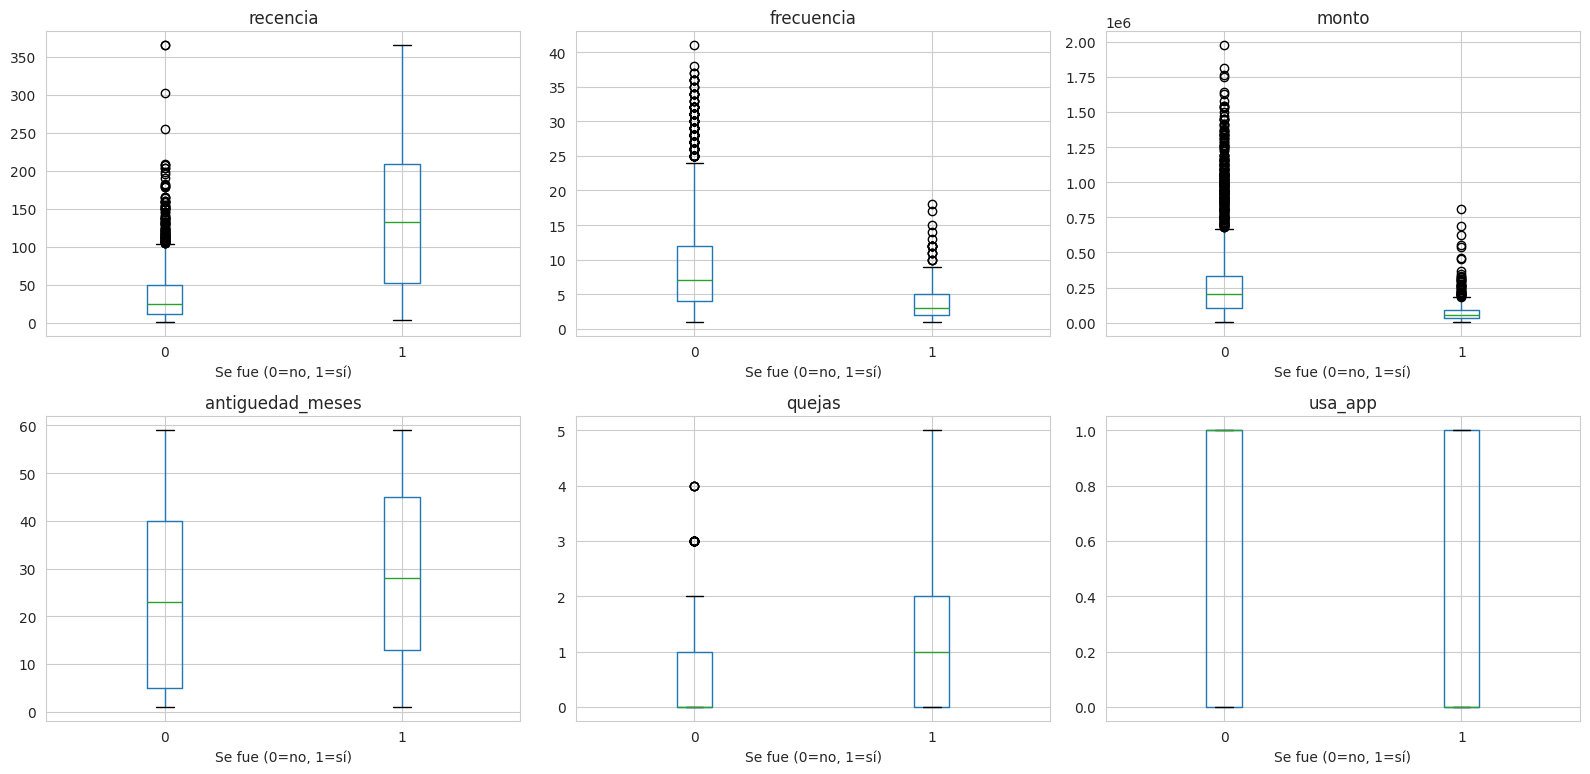

------------------------------------------------------------

 Tasa de abandono según uso de la app


,count,mean
No usa app,1072,0.271
Usa app,928,0.151


------------------------------------------------------------
Correlación de cada variable con el abandono 
frecuencia         -0.319
monto              -0.302
usa_app            -0.145
antiguedad_meses    0.090
quejas              0.314
recencia            0.595
se_fue              1.000
Name: se_fue, dtype: float64
------------------------------------------------------------
Tasa de abandono general: 21.5%


In [20]:
# Celda 5: PREGUNTA 1 · ¿Qué distingue a los clientes que se fueron?

# Comparamos promedios entre los que se quedaron y los que se fueron.
variables_numericas = ["recencia", "frecuencia", "monto", "antiguedad_meses", "quejas", "usa_app"]

comparacion = df_clientes.groupby("se_fue")[variables_numericas].mean().round(2)
comparacion.index = ["Se quedó (0)", "Se fue (1)"]
print("Promedios: Clientes que se quedaron vs. se fueron")
display(comparacion.T)
print("-" * 60)
# Graficos comparativos (boxplot para cada variable)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))                            # Cuadrícula de 2 filas x 3 columnas
for ax, col in zip(axes.ravel(), variables_numericas):                     # Recorre cada eje y cada variable
    df_clientes.boxplot(column=col, by="se_fue", ax=ax)                    # Boxplot de esa variable según se_fue
    ax.set_title(col)                                                       # Título del subgráfico
    ax.set_xlabel("Se fue (0=no, 1=sí)")                                    # Etiqueta del eje X
plt.suptitle("")                                                            # Quita el título automático de pandas
plt.tight_layout()                                                          # Ajusta los espacios
plt.show()
print("-" * 60)
# Tasa de abandono segun el uso de la app (variable categorica)
print("\n Tasa de abandono según uso de la app")
tabla_app = df_clientes.groupby("usa_app")["se_fue"].agg(["count", "mean"]).round(3)
tabla_app.index = ["No usa app", "Usa app"]
display(tabla_app)
print("-" * 60)
# Correlación de cada variable con se_fue (signo = dirección del efecto)
print("Correlación de cada variable con el abandono ")
print(df_clientes[variables_numericas + ["se_fue"]].corr()["se_fue"].round(3).sort_values())
print("-" * 60)
# Faltantes y tasas
print(f"Tasa de abandono general: {df_clientes['se_fue'].mean():.1%}")


#RESPUESTA PREGUNTA 1:

La tasa general de abandono es de 21.5% (430 de 2 000 clientes). Al comparar a los que se fueron con los que se quedaron:

| Variable | Se quedó | Se fue |
|---|---|---|
| Días sin comprar (recencia) | 37 | 142 |
| Compras (frecuencia) | 9.9 | 3.8 |
| Monto acumulado | 318 714 | 85 119 |
| Quejas | 0.50 | 1.14 |
| Antigüedad (meses) | 24.6 | 28.7 |

- **Días sin comprar:** es la señal más fuerte (correlación +0.60). El abandono es 7% en quienes compraron hace menos de 30 días, 51% entre 90 y 180 días, y 91% después de 180 días.
- **Frecuencia y monto:** los que se van compraron poco y gastaron mucho menos (correlaciones -0.32 y -0.30).
- **Quejas:** el abandono sube de 13% (sin quejas) a 48% (2 quejas) y 59% (3 quejas).
- **App:** quienes la usan se van menos (15% contra 27% de quienes no la usan).
- **Antigüedad:** casi no distingue a los grupos (correlación +0.09). Los que se fueron tienen incluso un poco más de antigüedad, así que no se puede decir que los clientes nuevos sean los que abandonan.

**Conclusión:** el abandono no es aleatorio. Quien se va lleva mucho tiempo sin comprar, compró pocas veces, gastó poco, tiene quejas y no usa la app.

# PARTE C · SEGMENTACIÓN DE CLIENTES (Unidad 4 · Aprendizaje no supervisado)

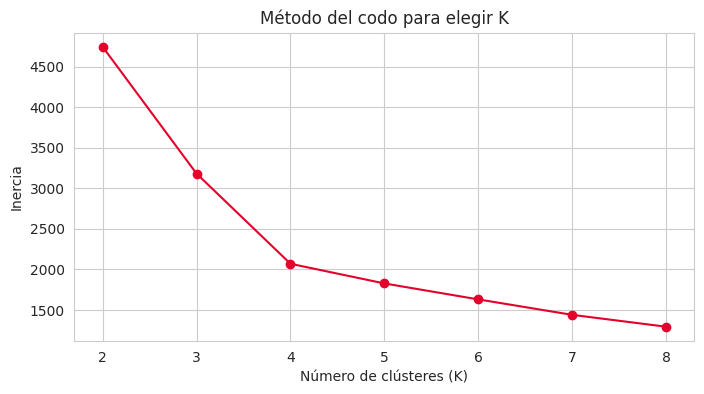

------------------------------------------------------------
Perfil de los 4 segmentos


,n_clientes,recencia,frecuencia,monto,antiguedad,quejas,usa_app,tasa_churn
Campeones,291,9.65,25.36,947006.19,28.45,0.40,0.80,0.01
Nuevos en crecimiento,786,35.33,5.66,192794.66,8.29,0.55,0.43,0.14
Veteranos tibios,655,47.32,7.13,149701.68,42.19,0.64,0.40,0.15
Dormidos,268,214.55,2.84,44073.51,31.96,1.16,0.36,0.82


------------------------------------------------------------


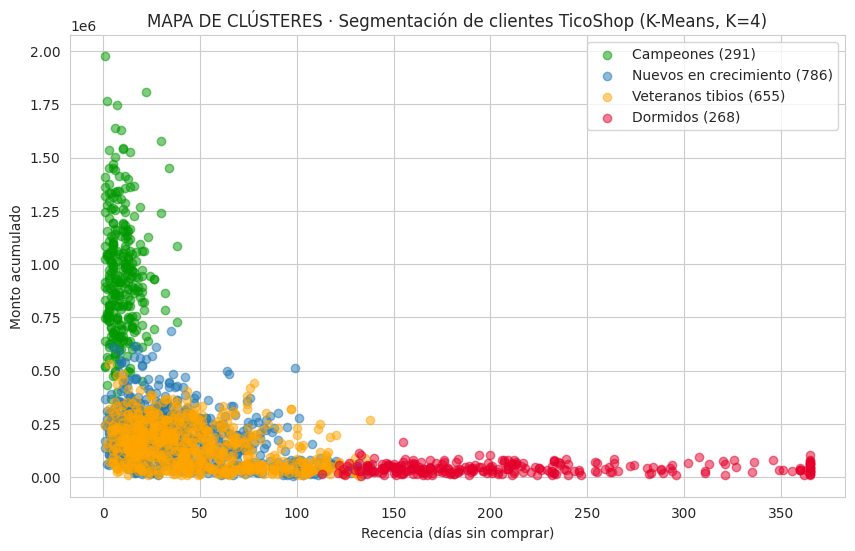

------------------------------------------------------------


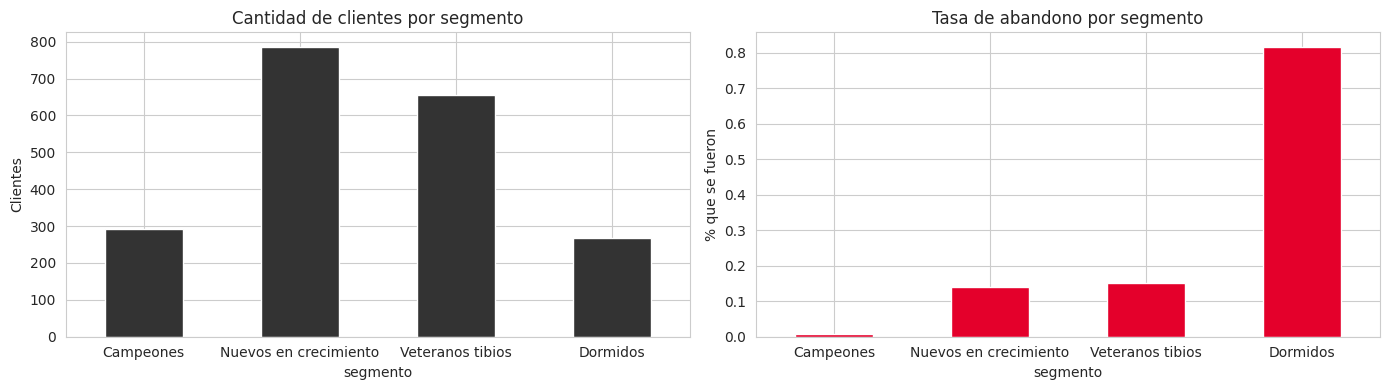

In [34]:
# Celda 6: PREGUNTA 2 · Segmentar clientes con K-Means

# Variables que usaremos para agrupar
variables_segmentacion = ["recencia", "frecuencia", "monto", "antiguedad_meses"]

# Escalar: K-Means usa distancias y "monto" (miles) dominaría a "frecuencia" (1 a 50)
scaler = StandardScaler()                                                  # Creamos el escalador
datos_scaled = scaler.fit_transform(df_clientes[variables_segmentacion])   # Escalamos los datos

# Método del codo para elegir K
inercias = []                                                              # Guarda la inercia de cada K
rango_k = range(2, 9)                                                      # Probamos K = 2, 3, ..., 8
for k in rango_k:                                                          # Recorre cada K
    km = KMeans(n_clusters=k, random_state=42, n_init=10)                  # Crea K-Means con ese K
    km.fit(datos_scaled)                                                   # Entrena con los datos escalados
    inercias.append(km.inertia_)                                           # Guarda la inercia

plt.figure(figsize=(8, 4))                                                 # Nueva figura
plt.plot(rango_k, inercias, marker="o", color="#E4002B")                   # Curva de inercia
plt.title("Método del codo para elegir K")                                 # Título
plt.xlabel("Número de clústeres (K)")                                      # Etiqueta X
plt.ylabel("Inercia")                                                      # Etiqueta Y
plt.xticks(rango_k)                                                        # Marcas del eje X
plt.show()                                                                 # Muestra el gráfico
print("-" * 60)

# Aplicar K-Means con K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)                  # 4 grupos
df_clientes["cluster"] = kmeans.fit_predict(datos_scaled)                  # Asigna cada cliente a un cluster

# Perfil de cada grupo (promedios)
analisis = df_clientes.groupby("cluster").agg(                             # Agrupa por cluster y calcula promedios
    n_clientes=("cliente_id", "count"),
    recencia=("recencia", "mean"),
    frecuencia=("frecuencia", "mean"),
    monto=("monto", "mean"),
    antiguedad=("antiguedad_meses", "mean"),
    quejas=("quejas", "mean"),
    usa_app=("usa_app", "mean"),
    tasa_churn=("se_fue", "mean")
).round(2)

# Nombrar los grupos por su COMPORTAMIENTO (no por su tasa de abandono)
nombre_por_cluster = {}                                                    # Diccionario cluster -> nombre
nombre_por_cluster[analisis["recencia"].idxmax()] = "Dormidos"             # El que lleva más días sin comprar
resto = analisis.drop(index=analisis["recencia"].idxmax())                 # Quitamos Dormidos
nombre_por_cluster[resto["monto"].idxmax()] = "Campeones"                  # El que más gasta y compra
resto = resto.drop(index=resto["monto"].idxmax())                          # Quitamos Campeones
nombre_por_cluster[resto["antiguedad"].idxmin()] = "Nuevos en crecimiento" # El más reciente (pocos meses)
nombre_por_cluster[resto["antiguedad"].idxmax()] = "Veteranos tibios"      # El más antiguo, con compra moderada
df_clientes["segmento"] = df_clientes["cluster"].map(nombre_por_cluster)   # Aplica el nombre a cada cliente

nombres = ["Campeones", "Nuevos en crecimiento", "Veteranos tibios", "Dormidos"]   # Orden fijo para gráficos
analisis.index = [nombre_por_cluster[c] for c in analisis.index]           # Cambia el índice por el nombre
print("Perfil de los 4 segmentos")
display(analisis.reindex(nombres))
print("-" * 60)

# Mapa de clústeres (gráfico de dispersión)
plt.figure(figsize=(10, 6))                                                # Nueva figura grande
colores = {"Campeones": "#009900",                                         # Verde = los mejores
           "Nuevos en crecimiento": "#1f77b4",                             # Azul = recién llegados
           "Veteranos tibios": "#FFA500",                                  # Naranja = compra moderada
           "Dormidos": "#E4002B"}                                          # Rojo = casi perdidos
for seg in nombres:                                                        # Recorre cada segmento
    sub = df_clientes[df_clientes["segmento"] == seg]                      # Filtra los clientes de ese segmento
    plt.scatter(sub["recencia"], sub["monto"], alpha=0.5,                  # Dibuja los puntos
                label=f"{seg} ({len(sub)})", color=colores[seg])           # Con su nombre y color
plt.xlabel("Recencia (días sin comprar)")                                  # Etiqueta X
plt.ylabel("Monto acumulado")                                              # Etiqueta Y
plt.title("MAPA DE CLÚSTERES · Segmentación de clientes TicoShop (K-Means, K=4)")
plt.legend()                                                               # Muestra la leyenda
plt.show()
print("-" * 60)

# Barras: tamaño y abandono de cada segmento
fig, axes = plt.subplots(1, 2, figsize=(14, 4))                            # Dos gráficos lado a lado
resumen_seg = df_clientes.groupby("segmento").agg(                         # Resumen por segmento
    n=("cliente_id", "count"),
    churn=("se_fue", "mean")
).reindex(nombres)                                                         # Orden fijo
resumen_seg["n"].plot(kind="bar", ax=axes[0], color="#333333")             # Cantidad de clientes
axes[0].set_title("Cantidad de clientes por segmento")
axes[0].set_ylabel("Clientes")
axes[0].tick_params(axis="x", rotation=0)
resumen_seg["churn"].plot(kind="bar", ax=axes[1], color="#E4002B")         # Tasa de abandono
axes[1].set_title("Tasa de abandono por segmento")
axes[1].set_ylabel("% que se fueron")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


#RESPUESTA PREGUNTA 2:

Se aplicó K-Means sobre recencia, frecuencia, monto y antigüedad, todas escaladas. Se usó el método del codo como referencia y se eligió K=4 porque produce grupos que se distinguen bien y se pueden atender de forma distinta. Los nombres se pusieron según el **comportamiento** de cada grupo (no según su tasa de abandono):

| Segmento | Clientes | Días sin comprar | Compras | Monto | Antigüedad (meses) | Usa app | Abandono |
|---|---|---|---|---|---|---|---|
| Campeones | 291 | 10 | 25 | 947 006 | 28 | 80% | 1% |
| Nuevos en crecimiento | 786 | 35 | 5.7 | 192 795 | 8 | 43% | 14% |
| Veteranos tibios | 655 | 47 | 7.1 | 149 702 | 42 | 40% | 15% |
| Dormidos | 268 | 215 | 2.8 | 44 074 | 32 | 36% | 82% |

- **Campeones:** compran con mucha frecuencia (25 compras en promedio) y gastan mucho. Casi nunca se van y son el motor de ventas.
- **Nuevos en crecimiento:** clientes con unos 8 meses, con compras recientes y gasto medio. Es el grupo más grande y todavía está formando el hábito.
- **Veteranos tibios:** clientes de más de 3 años que compran poco y gastan menos. Llevan algo más de tiempo sin comprar que los nuevos, por eso conviene vigilarlos.
- **Dormidos:** llevan más de 7 meses sin comprar, con pocas compras y más quejas. 219 de 268 ya se fueron.

Los dos grupos intermedios tienen un abandono casi igual (14% y 15%): lo que los separa es la antigüedad, no el riesgo. El grupo de mayor riesgo claro es Dormidos.

#PARTE D · MODELOS SUPERVISADOS PARA PREDECIR ABANDONO (Unidad 3)

In [23]:
# Celda 7: Separar X e Y y apartar los datos de prueba
columnas_X = ["recencia", "frecuencia", "monto",                     # Las pistas que usará el modelo
              "antiguedad_meses", "quejas", "usa_app"]
X = df_clientes[columnas_X]                                          # X va en doble corchete porque es una tabla
y = df_clientes["se_fue"]                                            # y va en un solo corchete porque es una columna (serie)

# test_size=0.3 → 30% para el examen
# stratify=y → mantiene la misma proporción de abandonos en ambos grupos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Entrenamiento: {len(X_train)} clientes | Prueba: {len(X_test)} clientes")
print(f"% que se fue en entrenamiento: {y_train.mean():.1%}")
print(f"% que se fue en prueba:        {y_test.mean():.1%}   (casi idéntico gracias a stratify)")



Entrenamiento: 1400 clientes | Prueba: 600 clientes
% que se fue en entrenamiento: 21.5%
% que se fue en prueba:        21.5%   (casi idéntico gracias a stratify)


In [38]:
# Celda 8: Entrenar 5 modelos, predecir y evaluar
#Nota: KNN necesita escalado previo, por eso usamos un pipeline con StandardScaler
from sklearn.pipeline import make_pipeline

modelos = {
    "Regresión logística":  LogisticRegression(max_iter=5000, random_state=42),
    "Árbol sin límite":     DecisionTreeClassifier(random_state=42),
    "Árbol limitado (d=3)": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Random Forest":        RandomForestClassifier(n_estimators=200, max_depth=6,
                                                    random_state=42,
                                                    class_weight="balanced"),
    "KNN (k=5)":            make_pipeline(StandardScaler(),
                                           KNeighborsClassifier(n_neighbors=5)),
}

# Línea base: un "modelo" que dice que NADIE se va acertaría esta proporción
print(f"Línea base (todos se quedan): accuracy = {1 - y_test.mean():.3f}")   # Referencia para comparar
print("-" * 60)

resultados = []                                                       # Aquí se guardan las métricas
predicciones = {}                                                     # Aquí se guardan las predicciones (para matrices)
probabilidades = {}                                                   # Aquí se guardan las probabilidades (para ROC)

for nombre, modelo in modelos.items():                                # Recorre cada modelo
    modelo.fit(X_train, y_train)                                      # Entrenar: el modelo aprende con los datos de práctica
    pred_train = modelo.predict(X_train)                              # Predice sobre los datos con los que aprendió
    pred_test  = modelo.predict(X_test)                               # Predice sobre el examen
    prob_test  = modelo.predict_proba(X_test)[:, 1]                   # Probabilidad de la clase "se fue"

    predicciones[nombre]  = pred_test                                 # Guarda predicciones
    probabilidades[nombre] = prob_test                                # Guarda probabilidades

    resultados.append({                                               # Guarda una fila de métricas
        "modelo": nombre,
        "accuracy_train": accuracy_score(y_train, pred_train),
        "accuracy_test":  accuracy_score(y_test,  pred_test),
        "precision_test": precision_score(y_test, pred_test),
        "recall_test":    recall_score(y_test,    pred_test),
        "auc_test":       roc_auc_score(y_test,   prob_test),
    })


tabla = pd.DataFrame(resultados).set_index("modelo")                  # Convierte la lista en tabla
tabla["brecha (train - test)"] = tabla["accuracy_train"] - tabla["accuracy_test"]  # Si es grande, hay sobreajuste
display(tabla.round(3).sort_values("recall_test", ascending=False))   # Ordena por Recall (lo más importante aquí)

Línea base (todos se quedan): accuracy = 0.785
------------------------------------------------------------


,accuracy_train,accuracy_test,precision_test,recall_test,auc_test,brecha (train - test)
modelo,,,,,,
Random Forest,0.881,0.827,0.584,0.674,0.842,0.055
Regresión logística,0.874,0.870,0.774,0.558,0.864,0.004
Árbol sin límite,1.000,0.792,0.516,0.512,0.690,0.208
KNN (k=5),0.886,0.852,0.727,0.496,0.800,0.034
Árbol limitado (d=3),0.876,0.867,0.845,0.465,0.827,0.009


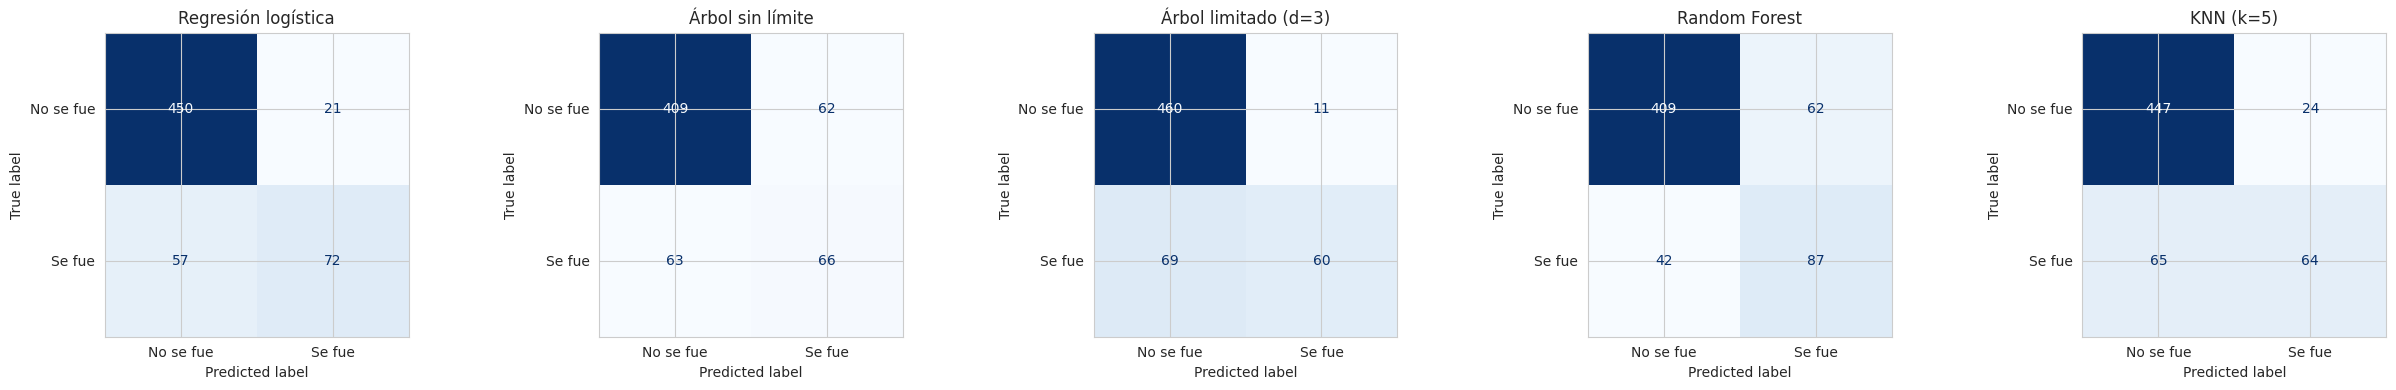

In [25]:
# Celda 9a: Matrices de confusión dibujadas (una por modelo)

fig, ejes = plt.subplots(1, 5, figsize=(25, 4))                        # Cinco gráficos lado a lado
for eje, nombre in zip(ejes, modelos):                                 # Recorre cada eje y cada modelo
    ConfusionMatrixDisplay.from_predictions(                           # Dibuja la matriz de confusión
        y_test, predicciones[nombre],
        display_labels=["No se fue", "Se fue"],
        cmap="Blues", ax=eje, colorbar=False)
    eje.set_title(nombre)                                              # Título del subgráfico
plt.tight_layout()
plt.show()

In [39]:
# Celda 9b: ¿Qué tan útil es el modelo?

# Números concretos de la matriz de confusión
filas = []                                                             # Aquí guardamos una fila por modelo
for nombre in modelos:                                                 # Recorre cada modelo
    tn, fp, fn, tp = confusion_matrix(y_test, predicciones[nombre]).ravel()   # Desarma la matriz
    filas.append({"modelo": nombre,
                  "se fueron (real)": tp + fn,                         # Total de abandonos en la prueba
                  "detectados": tp,                                    # Abandonos que el modelo atrapó
                  "se escaparon": fn,                                  # Abandonos que el modelo no vio
                  "falsas alarmas": fp})                               # Clientes contactados sin necesidad
display(pd.DataFrame(filas).set_index("modelo"))
print("-" * 60)

# Abandono según días sin comprar
bandas = pd.cut(df_clientes["recencia"], [0, 30, 60, 90, 180, 365])   # Rangos de recencia
display(df_clientes.groupby(bandas, observed=True)["se_fue"].agg(["count", "mean"]).round(3))
print("-" * 60)

# ¿Qué tanto depende el modelo de la recencia? Random Forest SIN esa variable
sin_rec = [c for c in columnas_X if c != "recencia"]                   # Todas menos recencia
rf_sin = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42,
                                class_weight="balanced").fit(X_train[sin_rec], y_train)
print(f"Random Forest sin recencia: AUC = {roc_auc_score(y_test, rf_sin.predict_proba(X_test[sin_rec])[:, 1]):.3f}"
      f"  |  recall = {recall_score(y_test, rf_sin.predict(X_test[sin_rec])):.3f}")

,se fueron (real),detectados,se escaparon,falsas alarmas
modelo,,,,
Regresión logística,129,72,57,21
Árbol sin límite,129,66,63,62
Árbol limitado (d=3),129,60,69,11
Random Forest,129,87,42,62
KNN (k=5),129,64,65,24


------------------------------------------------------------


,count,mean
recencia,,
"(0, 30]",968,0.073
"(30, 60]",423,0.123
"(60, 90]",208,0.192
"(90, 180]",245,0.510
"(180, 365]",156,0.910


------------------------------------------------------------
Random Forest sin recencia: AUC = 0.795  |  recall = 0.752


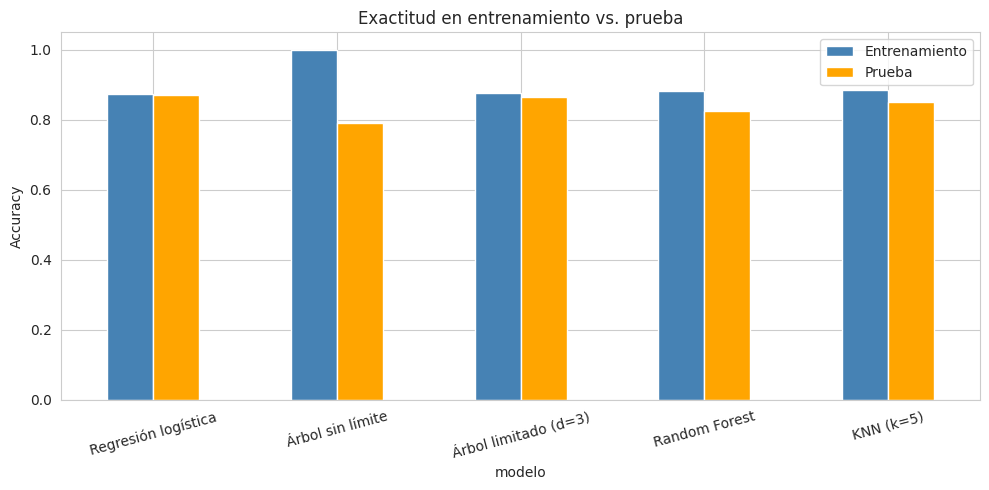

In [26]:
# Celda 10: Comparar entrenamiento vs. prueba (detectar sobreajuste)
tabla[["accuracy_train", "accuracy_test"]].plot(                       # Barras comparativas
    kind="bar", figsize=(10, 5), color=["steelblue", "orange"])
plt.title("Exactitud en entrenamiento vs. prueba")                     # Título
plt.ylabel("Accuracy")                                                 # Etiqueta Y
plt.ylim(0, 1.05)                                                      # Rango del eje Y
plt.xticks(rotation=15)                                                # Nombres de modelos rotados
plt.legend(["Entrenamiento", "Prueba"])                                # Leyenda
plt.tight_layout()
plt.show()

In [27]:
# Celda 11: Validación cruzada (5 pliegues) SOLO con los datos de entrenamiento

# Sirve para confirmar que la nota no depende de una sola división de los datos.
notas_cv = {}                                                          # Guarda promedios
for nombre, modelo in modelos.items():                                 # Recorre cada modelo
    notas = cross_val_score(modelo, X_train, y_train, cv=5, scoring="accuracy")  # 5 pruebas
    notas_cv[nombre] = notas.mean()                                    # Guarda el promedio
    print(f"{nombre:25} promedio = {notas.mean():.3f}  (variación ±{notas.std():.3f})")


Regresión logística       promedio = 0.872  (variación ±0.011)
Árbol sin límite          promedio = 0.776  (variación ±0.013)
Árbol limitado (d=3)      promedio = 0.861  (variación ±0.012)
Random Forest             promedio = 0.829  (variación ±0.022)
KNN (k=5)                 promedio = 0.859  (variación ±0.022)


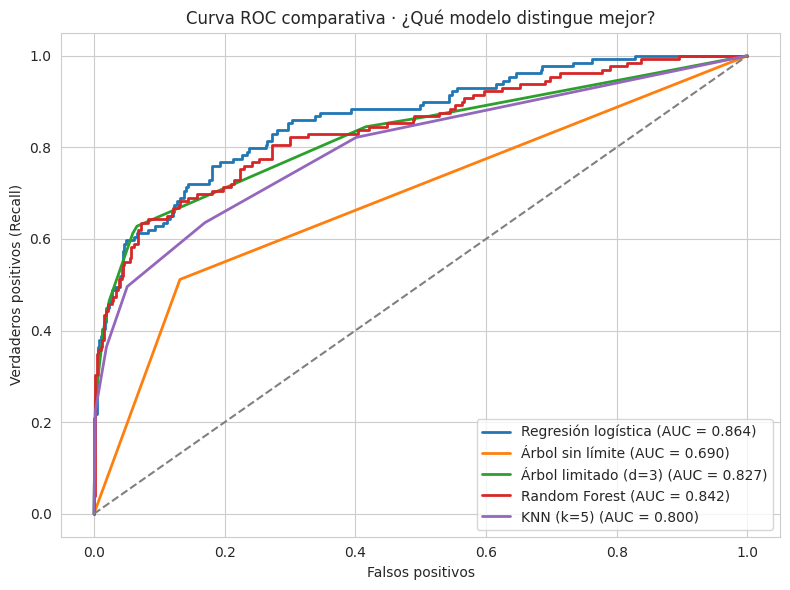

In [28]:
# Celda 12: Curva ROC comparativa (todos los modelos en un gráfico)

plt.figure(figsize=(8, 6))                                             # Nueva figura
for nombre in modelos:                                                 # Recorre cada modelo
    fpr, tpr, _ = roc_curve(y_test, probabilidades[nombre])            # Calcula la curva ROC
    auc = roc_auc_score(y_test, probabilidades[nombre])                # Calcula el AUC
    plt.plot(fpr, tpr, lw=2, label=f"{nombre} (AUC = {auc:.3f})")      # Dibuja la curva
plt.plot([0, 1], [0, 1], "--", color="gray")                           # Línea diagonal (modelo al azar)
plt.xlabel("Falsos positivos")                                         # Etiqueta X
plt.ylabel("Verdaderos positivos (Recall)")                            # Etiqueta Y
plt.title("Curva ROC comparativa · ¿Qué modelo distingue mejor?")      # Título
plt.legend(loc="lower right")                                          # Leyenda abajo a la derecha
plt.tight_layout()
plt.show()

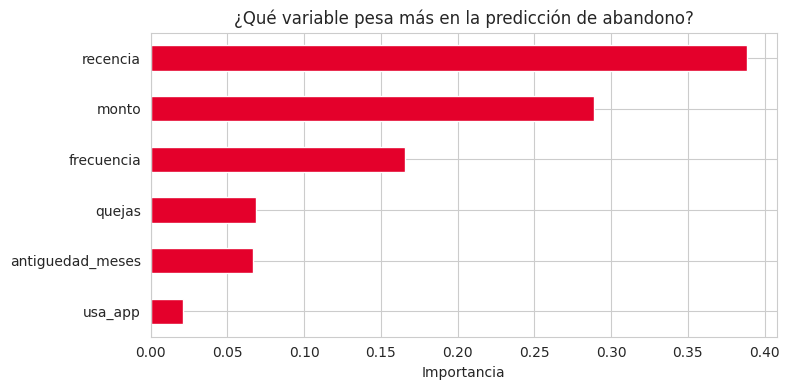

------------------------------------------------------------
Importancia de cada variable (Random Forest)
recencia            0.389
monto               0.289
frecuencia          0.166
quejas              0.069
antiguedad_meses    0.067
usa_app             0.021
dtype: float64
------------------------------------------------------------
Coeficientes escalados (positivo = sube el riesgo de irse, negativo = lo baja)
frecuencia         -1.133
usa_app            -0.327
monto              -0.121
antiguedad_meses   -0.033
quejas              0.403
recencia            1.199
dtype: float64
------------------------------------------------------------
Abandono según número de quejas


,count,mean
quejas,,
0,1092,0.127
1,624,0.232
2,212,0.481
3,59,0.593
4,11,0.636
5,2,1.000


Abandono según antigüedad


,count,mean
antiguedad_meses,,
"(0, 12]",669,0.157
"(12, 24]",336,0.256
"(24, 36]",354,0.229
"(36, 60]",641,0.246


In [36]:
# Celda 13: PREGUNTA 4 · Importancia de variables (con el Random Forest)

# El Random Forest mide importancia de variables de forma más robusta que un árbol solo.
importancias = pd.Series(                                              # Serie con la importancia de cada variable
    modelos["Random Forest"].feature_importances_, index=columnas_X
).sort_values()                                                        # Ordena de menor a mayor

plt.figure(figsize=(8, 4))                                             # Nueva figura
importancias.plot(kind="barh", color="#E4002B")                        # Barras horizontales
plt.title("¿Qué variable pesa más en la predicción de abandono?")      # Título
plt.xlabel("Importancia")                                              # Etiqueta X
plt.tight_layout()
plt.show()
print("-"*60)
print("Importancia de cada variable (Random Forest)")
print(importancias.round(3).sort_values(ascending=False))

# Coeficientes de la regresión logística CON variables escaladas
# (sin escalar no se pueden comparar: monto va en miles y usa_app es 0/1)
logistica_escalada = make_pipeline(StandardScaler(),                   # Escala y luego ajusta la logística
                                   LogisticRegression(max_iter=5000, random_state=42))
logistica_escalada.fit(X_train, y_train)                               # Entrena con el mismo train
coef = pd.Series(logistica_escalada[-1].coef_[0], index=columnas_X).round(3)   # Coeficientes comparables
print("-"*60)
print("Coeficientes escalados (positivo = sube el riesgo de irse, negativo = lo baja)")
print(coef.sort_values())

# Abandono por cantidad de quejas y por antigüedad (para confirmar el efecto)
print("-"*60)
print("Abandono según número de quejas")
display(df_clientes.groupby("quejas")["se_fue"].agg(["count", "mean"]).round(3))
print("Abandono según antigüedad")
display(df_clientes.groupby(pd.cut(df_clientes["antiguedad_meses"], [0, 12, 24, 36, 60]),
                            observed=True)["se_fue"].agg(["count", "mean"]).round(3))

#RESPUESTA PREGUNTA 3:

Se entrenaron 5 modelos con las mismas variables y los mismos datos de entrenamiento (70%), y se evaluaron con el 30% apartado (600 clientes, 129 de ellos se fueron). Como solo el 21.5% abandona, hay que comparar contra una **línea base**: un "modelo" que diga que nadie se va acierta 78.5%. Por eso la exactitud sola engaña y se priorizó el **recall** (cuántos de los que se van se detectan).

| Modelo | Exactitud prueba | Precisión | Recall | AUC | Validación cruzada |
|---|---|---|---|---|---|
| Regresión logística | 0.870 | 0.774 | 0.558 | 0.864 | 0.872 |
| Árbol limitado (d=3) | 0.867 | 0.845 | 0.465 | 0.827 | 0.861 |
| KNN (k=5) | 0.852 | 0.727 | 0.496 | 0.800 | 0.859 |
| Random Forest | 0.827 | 0.584 | 0.674 | 0.842 | 0.829 |
| Árbol sin límite | 0.792 | 0.516 | 0.512 | 0.690 | 0.776 |

- **Árbol sin límite:** acierta 100% en entrenamiento y solo 79.2% en prueba, apenas sobre la línea base. Memorizó (sobreajuste, brecha de 21 puntos).
- **Regresión logística:** la mejor en exactitud, AUC y validación cruzada, y la que menos falsas alarmas genera (21). Detecta 72 de los 129 que se van.
- **Random Forest:** es el que más abandonos detecta (87 de 129; se escapan 42), a cambio de 62 falsas alarmas (clientes contactados que no se iban a ir).
- **Elección:** Random Forest para detectar y ordenar la lista de contacto, porque un cupón de más cuesta poco comparado con un cliente perdido. Frente a la logística atrapa 15 abandonos más a cambio de 41 falsas alarmas más, así que conviene mientras salvar a un cliente valga más de unos 3 cupones (cálculo aproximado, que supone que todo cliente contactado en riesgo se logra retener). Si la empresa tuviera un presupuesto muy limitado, la regresión logística (explicable y con menos falsas alarmas) sería la alternativa.

**¿Qué tan útil sería?** Sirve para ordenar a los clientes de mayor a menor riesgo y enfocar el esfuerzo, pero no es perfecto: aun el mejor modelo deja escapar a unos 3 de cada 10 clientes que se van (42 de 129 con el Random Forest). Además, los días sin comprar casi definen el abandono (91% de los que pasan 180 días ya se fue), así que el valor está en el grupo de 30 a 180 días, que todavía se puede recuperar. Sin esa variable el Random Forest baja su AUC de 0.842 a 0.795, o sea que aún detecta con las demás variables, pero con menos fuerza.

La matriz de confusión está en las Celdas 9a y 9b, la validación cruzada en la Celda 11 y la curva ROC en la Celda 12. En la validación cruzada gana la logística; el Random Forest se elige por recall, no por exactitud.

#RESPUESTA PREGUNTA 4:

Se usó la importancia de variables del Random Forest (recencia 0.39, monto 0.29, frecuencia 0.17, quejas 0.07, antigüedad 0.07, app 0.02) y los coeficientes de la regresión logística **con variables escaladas**, que sí se pueden comparar entre sí: recencia +1.20, quejas +0.40, app -0.33, monto -0.12, frecuencia -1.13 y antigüedad -0.03.

**Factores que aumentan el riesgo de irse**
- **Muchos días sin comprar** (el más fuerte): el abandono pasa de 7% (menos de 30 días) a 51% (90 a 180 días) y 91% (más de 180 días).
- **Quejas:** 13% de abandono sin quejas, 48% con 2 y 59% con 3.

**Factores que disminuyen el riesgo**
- **Comprar con frecuencia:** quien compra seguido ya tiene el hábito. Los clientes con 3 compras o menos abandonan 42%.
- **Monto alto:** el Random Forest lo ubica segundo, pero en la logística pesa poco porque está muy ligado a la frecuencia (quien compra más, gasta más).
- **Usar la app:** el abandono es 15% con app y 27% sin app. Es una asociación: puede que los clientes más comprometidos usen más la app, no que la app los retenga por sí sola.

**Lo que NO pesa:** la antigüedad (coeficiente casi 0). Los clientes de menos de 12 meses abandonan 16% y los demás entre 23% y 26%.

**Qué significa para TicoShop:** el mejor aviso temprano es el silencio del cliente, seguido de las quejas sin resolver. La empresa debería activar una alerta cuando un cliente pase de unos 60 días sin comprar (ahí el abandono aún es 19%; después de 90 días sube a 51%) y atender rápido a quien acumula quejas.

# PARTE E · PREGUNTA 5 · PLAN DE ACCIÓN PARA LA GERENTE DE MERCADEO

Clientes activos: 1570 de 2000
------------------------------------------------------------
Resumen por segmento (solo clientes activos, priorizado por impacto)


,n_activos,prob_promedio,monto_promedio,en_riesgo_alto,prioridad_total
segmento,,,,,
Nuevos en crecimiento,676,0.26,200218.64,229,27659686.45
Veteranos tibios,556,0.25,160000.00,223,13452243.08
Campeones,289,0.02,948606.92,0,5034146.20
Dormidos,49,0.77,39295.92,49,1497235.70


------------------------------------------------------------


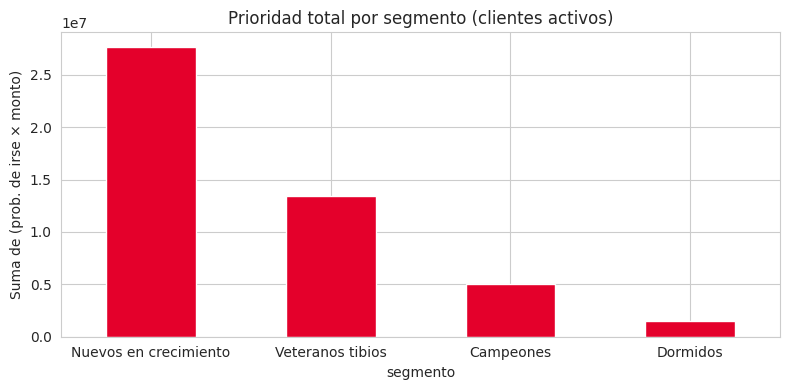

------------------------------------------------------------
=== TOP 30 CLIENTES ACTIVOS A CONTACTAR ESTA SEMANA ===


,cliente_id,segmento,recencia,frecuencia,monto,quejas,usa_app,prob_churn,prioridad
288,C0289,Nuevos en crecimiento,25,7,570300,0,0,0.29,167787.70
647,C0648,Nuevos en crecimiento,19,7,560000,0,0,0.27,149646.63
1581,C1582,Nuevos en crecimiento,27,8,609300,0,0,0.24,146148.49
1764,C1765,Nuevos en crecimiento,18,8,602700,0,0,0.22,135104.12
1209,C1210,Nuevos en crecimiento,20,5,520300,1,0,0.25,132088.09
1617,C1618,Nuevos en crecimiento,42,7,469200,1,1,0.26,124031.35
1366,C1367,Nuevos en crecimiento,11,8,461900,2,1,0.26,118331.74
1774,C1775,Nuevos en crecimiento,99,6,515300,0,1,0.23,116795.27
1319,C1320,Nuevos en crecimiento,20,7,525600,0,0,0.22,114059.43
1149,C1150,Nuevos en crecimiento,65,9,482700,0,0,0.23,112549.24


Segmentos del Top 30:
segmento
Nuevos en crecimiento    27
Campeones                 2
Veteranos tibios          1
Name: count, dtype: int64
------------------------------------------------------------


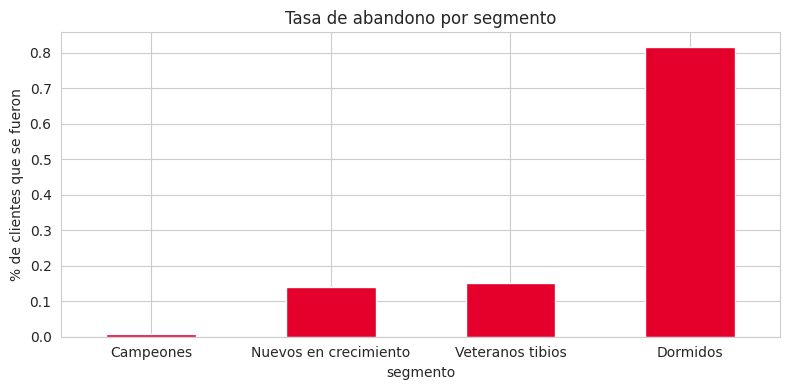

In [37]:
# Celda 14: Lista priorizada de clientes a contactar (solo los que TODAVÍA no se han ido)

mejor_modelo = modelos["Random Forest"]                                # Modelo elegido para detectar
df_clientes["prob_churn"] = mejor_modelo.predict_proba(X)[:, 1]        # Probabilidad de irse de cada cliente

# Prioridad = probabilidad de irse × valor del cliente (monto)
df_clientes["prioridad"] = df_clientes["prob_churn"] * df_clientes["monto"]

# Solo tiene sentido contactar a quienes siguen activos (se_fue = 0)
activos = df_clientes[df_clientes["se_fue"] == 0].copy()               # Clientes que aún compran
print(f"Clientes activos: {len(activos)} de {len(df_clientes)}")
print("-"*60)

# Resumen por segmento, solo con clientes activos
resumen = activos.groupby("segmento").agg(                             # Agrupa por segmento
    n_activos=("cliente_id", "count"),
    prob_promedio=("prob_churn", "mean"),
    monto_promedio=("monto", "mean"),
    en_riesgo_alto=("prob_churn", lambda s: (s >= 0.30).sum()),        # Activos con 30% o más de riesgo
    prioridad_total=("prioridad", "sum")
).round(2).sort_values("prioridad_total", ascending=False)             # Ordena por impacto
print("Resumen por segmento (solo clientes activos, priorizado por impacto)")
display(resumen)
print("-"*60)

resumen["prioridad_total"].plot(kind="bar", color="#E4002B", figsize=(8, 4))   # Gráfico de impacto
plt.title("Prioridad total por segmento (clientes activos)")
plt.ylabel("Suma de (prob. de irse × monto)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print("-"*60)

# Top 30 clientes activos a contactar esta semana
top30 = activos.sort_values("prioridad", ascending=False).head(30)     # Los 30 de mayor prioridad
print("=== TOP 30 CLIENTES ACTIVOS A CONTACTAR ESTA SEMANA ===")
display(top30[["cliente_id", "segmento", "recencia", "frecuencia",
               "monto", "quejas", "usa_app",
               "prob_churn", "prioridad"]].round(2))
print("Segmentos del Top 30:")
print(top30["segmento"].value_counts())
print("-"*60)

# Abandono observado por segmento
df_clientes.groupby("segmento")["se_fue"].mean().reindex(nombres).plot(
    kind="bar", color="#E4002B", figsize=(8, 4))
plt.title("Tasa de abandono por segmento")
plt.ylabel("% de clientes que se fueron")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#RESPUESTA PREGUNTA 5:

PLAN DE ACCIÓN PARA LA GERENTE DE MERCADEO

Hoy TicoShop tiene 1 570 clientes que todavía compran. A ellos hay que enfocar los esfuerzos: contactar a quien ya se fue (430 clientes) no es retención. La prioridad combina qué tan probable es que se vayan y cuánto compran.

**1) Prioridad alta: "Nuevos en crecimiento" (676 clientes activos, 229 con riesgo alto)**
- Es el grupo donde está más dinero en juego: son muchos y gastan en promedio 200 mil.
- Estrategia: mensaje o llamada personal de seguimiento ("¿cómo le fue con su compra?"), un cupón del 15% para la próxima compra y una invitación a usar la app.
- Por qué: todavía están formando el hábito de compra y, si no vuelven pronto, se pierden. 27 de los 30 clientes más urgentes de esta semana son de este grupo.

**2) Prioridad alta, en paralelo: clientes con 2 o más quejas (138 activos)**
- Estrategia: una llamada para resolver el problema antes de ofrecer cualquier descuento.
- Por qué: la mitad de los clientes con 2 o más quejas ya se fue.

**3) Prioridad media: "Veteranos tibios" (556 clientes activos, 223 con riesgo alto)**
- Estrategia: correo "te extrañamos" con recomendaciones de lo que compraron antes y un cupón del 15%, enviado antes de que cumplan 90 días sin comprar.
- Por qué: llevan bastante tiempo con la tienda pero compran poco. Entre los 90 y 180 días sin comprar, la mitad se va.

**4) Prioridad baja: "Dormidos" (49 clientes activos)**
- Estrategia: un único correo automático con un descuento fuerte; si no responden, dejarlos ir.
- Por qué: 8 de cada 10 ya se fueron y no vale la pena invertir más.

**5) Cuidar sin presionar: "Campeones" (289 clientes)**
- Estrategia: beneficios exclusivos, acceso anticipado a ofertas y atención preferencial. Solo a los pocos con quejas, una llamada personal.
- Por qué: casi nunca se van, pero perder a uno cuesta mucho porque gastan unas tres veces y media más que el cliente promedio.

**Plan concreto para esta semana**
1. Llamar a los 30 clientes de la lista (mezcla de alto riesgo y alto gasto) con una oferta personalizada según lo que compraron.
2. Pedir al equipo que avise cuando un cliente cumpla 60 días sin comprar, para escribirle ese mismo día.
3. Dejar sin contactar a un grupo pequeño de clientes parecidos, para comparar después cuántos se quedan con y sin llamada y medir si la campaña funciona.

En palabras sencillas: en lugar de mandar el mismo correo a los 2 000 clientes, ahora sabemos a quién llamar primero, con qué mensaje y por qué.

# PARTE F · CONCLUSIÓN FINAL

#CONCLUSIÓN FINAL DEL ANÁLISIS

Se analizaron los 2 000 clientes de TicoShop con dos enfoques: aprendizaje no supervisado (K-Means) para segmentarlos y aprendizaje supervisado (5 modelos) para predecir quién se va.

**1) Qué distingue a quienes se van:** muchos días sin comprar, pocas compras, bajo gasto, más quejas y no usar la app. La antigüedad casi no influye.

**2) Segmentación (K-Means, K=4):** Campeones (291), Nuevos en crecimiento (786), Veteranos tibios (655) y Dormidos (268). El abandono es de 1%, 14%, 15% y 82% respectivamente.

**3) Modelos:** la línea base (nadie se va) acierta 78.5%. El Random Forest detecta 87 de 129 abandonos (recall 67%, precisión 58%, AUC 0.84), a costa de 62 falsas alarmas. La regresión logística tiene el mejor AUC (0.86), mejor validación cruzada y menos falsas alarmas, pero detecta menos (72 de 129). El modelo sirve para ordenar y priorizar, no para acertar en todos los casos.

**4) Factores clave:** los días sin comprar y las quejas aumentan el riesgo; la frecuencia de compra, el monto y el uso de la app lo disminuyen (la app es una asociación, no una causa comprobada).

**5) Plan de acción:** enfocarse en los 1 570 clientes activos. Primero los Nuevos en crecimiento y los clientes con quejas, luego los Veteranos tibios, una sola campaña barata para los Dormidos y atención especial para los Campeones.

El valor del Machine Learning en TicoShop no está en acertar siempre, sino en **ordenar** a los clientes por riesgo y valor para que los recursos de retención se usen donde más impacto tienen.